# check data alignment of marketing, bookings dataset vs GA4
**Sources compared:**
- bookings
- marketing data (master marketing activites - KOL, CRM, FB)
- GA data (campaign impact, campaign outreach, session source, agg restaurants)

**Checks performed:**
1. Restaurant coverage overlap
3. Monthly booking volume vs GA4 metrics that relates to volume 
4. Monthly revenue comparison 
5. Campaign overlap 
6. Campaign month activity relationship

#### imports

In [78]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.dpi': 110,
    'figure.figsize': (12, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = sns.color_palette('tab10')

# ── Paths ─────────────────────────────────────────────────────────────────────
BOOKINGS_PATH     = Path('../data/mv_dataset_parquet/bookings.parquet')         
MASTER_MARKETING_PATH     = Path('../_3_marketing/master_marketing_activties.csv')         
GA4_IMPACT_PATH   = Path('../data/marketing/googleAPI/campaign_impact.parquet')
GA4_OUTREACH_PATH = Path('../data/marketing/googleAPI/campaigns_outreach.parquet')
GA4_SESSION_PATH  = Path('../data/marketing/googleAPI/session_source.parquet')   
GA4_AGG_REST  = Path('../data/marketing/googleAPI/agg_restaurants.parquet')   
GA4_AGG_ACTIVITY  = Path('../data/marketing/googleAPI/agg_user_activity.parquet')   

# ── Filter: only consider valid, arrived bookings for revenue comparisons ─────
# Adjust these flags to match your definition of a completed booking
VALID_BOOKING_FILTERS = {
    'is_valid_reservation': True,
    'arrived': True,
}


## Load & Prepare Data

### bookings data
- Valid bookings for analysis: 277,644
- Bookings total        : 349,385
- Unique restaurants    : 2,971
- Date range            : 2024-04-04 → 2026-12-31

In [43]:
# ── Bookings ──────────────────────────────────────────────────────────────────
bk = pd.read_parquet(BOOKINGS_PATH)
bk.columns

Index(['updated_at_non_null', 'ack', 'active', 'arrived', 'channel',
       'created_at', 'created_incremental_refresh', 'date', 'deleted_at',
       'email', 'for_locking_system', 'guest_id', 'id', 'is_order_now',
       'is_temporary', 'is_valid_reservation', 'medium', 'no_show',
       'party_size', 'phone', 'restaurant_id', 'total_price_v2_cents',
       'updated_at', 'used_voucher_amount_by_hh_cents',
       'used_voucher_amount_by_restaurant_cents', 'user_id',
       'voucher_added_at', 'voucher_id', 'restaurant_name', 'hh_package_type',
       'package_price', 'revenue', 'channel_name', 'user_email', 'username',
       'city_name', 'user_type', 'has_refund_guarantee',
       'refund_guarantee_status', 'refundable_amount_cents',
       'refund_guarantee_fee_cents', 'payment_type'],
      dtype='object')

In [44]:
# data prep for bookings
# drop duplicates
before_rows = len(bk)
bk.drop_duplicates(inplace=True)
after_rows = len(bk)

print(f"Duplicates removed: {before_rows - after_rows}")

# Parse dates
bk['date'] = pd.to_datetime(bk['date'], errors='coerce')
bk['created_at']   = pd.to_datetime(bk['created_at'],   errors='coerce')

# Month column for aggregations
bk['year_month'] = bk['date'].dt.to_period('M').dt.to_timestamp()

# Revenue in base currency (cents → THB)
bk['revenue_thb'] = pd.to_numeric(bk['revenue'], errors='coerce')
# If revenue is stored in cents, divide by 100:
# bk['revenue_thb'] = pd.to_numeric(bk['total_price_v2_cents'], errors='coerce') / 100

print(f'Bookings total        : {len(bk):,}')
print(f'Unique restaurants    : {bk["restaurant_id"].nunique():,}')
print(f'Date range            : {bk["date"].min().date()} → {bk["date"].max().date()}')
print(f'Channels              : {bk["channel_name"].dropna().unique().tolist()}')
print(f'\nColumn snapshot:')
display(bk.dtypes.to_frame('dtype').T)

Duplicates removed: 101545
Bookings total        : 349,385
Unique restaurants    : 2,971
Date range            : 2024-04-04 → 2026-12-31
Channels              : ['Hungry Hub', 'netcore', 'Website', 'Facebook', 'Google', 'HH-TJK', 'HH-MP', 'Reserve With Google', 'HH-KJT', 'LINE-BC', 'HH x Klook', 'HH x KKday', 'HH-MOO', 'HH-GBM', 'HH-EBF', 'Manual package by Owner', 'HH-PYB', 'HH x xplORe', 'Instagram', 'HH x OpenRice', 'HH-OTT', 'Restaurant Post', 'HH-OBB', 'HH-KWAN', 'HH-CVTP', 'Tiktok', 'HH-PKP', 'BLOG-TH', 'HH-HGJ', 'Dream Experience', 'HH x WAUG', 'HH x GetYourGuide', 'HH-PLS', 'HH-BOY', 'HH-UCD', 'HH-SETH', 'HH-RHOI', 'HH-CNLV', 'HH-GPM', 'HH-PLM', 'HH x SparkLove', 'HH-SOU', 'HH-BED', 'HH-AJ', 'HH-DNS', 'HH-IAE', 'HH-PNPK', 'HH x RoyalOrchidPlus', 'HH-BLOGGER', 'HH-HMRP', 'HH-UNCLE', 'Corporate', 'HH-RVST', 'HH-SNH', 'HH-FAD', 'HH-JPA', 'HH-DI', 'HH-PANTIP', 'Between', 'HH-NCK', 'HH-KMG', 'HH-TMD', 'HH-TWT', 'HH-JNJN', 'LINE-RM', 'HH-ESR', 'HH-HSPZ', 'HH-DMPK', 'Hungry Blog', 'HH

,updated_at_non_null,ack,active,arrived,channel,created_at,created_incremental_refresh,date,deleted_at,email,...,username,city_name,user_type,has_refund_guarantee,refund_guarantee_status,refundable_amount_cents,refund_guarantee_fee_cents,payment_type,year_month,revenue_thb
dtype,object,bool,bool,bool,int64,datetime64[ns],object,datetime64[ns],float64,object,...,object,object,object,int64,object,float64,float64,object,datetime64[ns],float64


In [45]:
# Apply valid-booking filters 
bk_valid = bk.copy()
for col, val in VALID_BOOKING_FILTERS.items():
    if col in bk_valid.columns:
        before = len(bk_valid)
        bk_valid = bk_valid[bk_valid[col] == val]
        print(f'  Filter [{col}=={val}]: {before:,} → {len(bk_valid):,} rows')

# Drop deleted
if 'deleted_at' in bk_valid.columns:
    before = len(bk_valid)
    bk_valid = bk_valid[bk_valid['deleted_at'].isna()]
    print(f'Filter [deleted_at is null]: {before:,} → {len(bk_valid):,} rows')

print(f'\nValid bookings for analysis: {len(bk_valid):,}')

print(f'Bookings total        : {len(bk):,}')
print(f'Unique restaurants    : {bk["restaurant_id"].nunique():,}')
print(f'Date range            : {bk["date"].min().date()} → {bk["date"].max().date()}')
print(f'Channels              : {bk["channel_name"].dropna().unique().tolist()}')

  Filter [is_valid_reservation==True]: 349,385 → 349,381 rows
  Filter [arrived==True]: 349,381 → 277,644 rows
Filter [deleted_at is null]: 277,644 → 277,644 rows

Valid bookings for analysis: 277,644
Bookings total        : 349,385
Unique restaurants    : 2,971
Date range            : 2024-04-04 → 2026-12-31
Channels              : ['Hungry Hub', 'netcore', 'Website', 'Facebook', 'Google', 'HH-TJK', 'HH-MP', 'Reserve With Google', 'HH-KJT', 'LINE-BC', 'HH x Klook', 'HH x KKday', 'HH-MOO', 'HH-GBM', 'HH-EBF', 'Manual package by Owner', 'HH-PYB', 'HH x xplORe', 'Instagram', 'HH x OpenRice', 'HH-OTT', 'Restaurant Post', 'HH-OBB', 'HH-KWAN', 'HH-CVTP', 'Tiktok', 'HH-PKP', 'BLOG-TH', 'HH-HGJ', 'Dream Experience', 'HH x WAUG', 'HH x GetYourGuide', 'HH-PLS', 'HH-BOY', 'HH-UCD', 'HH-SETH', 'HH-RHOI', 'HH-CNLV', 'HH-GPM', 'HH-PLM', 'HH x SparkLove', 'HH-SOU', 'HH-BED', 'HH-AJ', 'HH-DNS', 'HH-IAE', 'HH-PNPK', 'HH x RoyalOrchidPlus', 'HH-BLOGGER', 'HH-HMRP', 'HH-UNCLE', 'Corporate', 'HH-RVST', '

### marketing data
- Marketing activities : 5,984
- KOL Restaurants covered  : 301
- CRM Restaurants covered  : 257
- FB Restaurants covered  : 871
- FB unique campaigns  : 35
- KOL platforms      : ['Instagram' 'Tiktok' 'XHS' 'Lemon8' 'Facebook' 'Youtube' nan]
- data start date range   : 2021-03-16 → 2026-01-12
- data end date range   : 2021-03-21 → 2026-01-14

In [46]:
mkt = pd.read_csv(MASTER_MARKETING_PATH)

activity_start = pd.to_datetime(mkt["activity_start"], errors='coerce')
activity_end = pd.to_datetime(mkt["activity_end"], errors='coerce')

print(f'Marketing activities : {len(mkt):,}')
print(f'KOL Restaurants covered  : {mkt["kol_restaurant_name"].nunique():,}')
print(f'CRM Restaurants covered  : {mkt["crm_restaurant_id_raw"].nunique():,}')
print(f'FB Restaurants covered  : {mkt["fb_restaurant_name"].nunique():,}')
print(f'FB unique campaigns  : {mkt["fb_campaign"].nunique():,}')
print(f'KOL platforms      : {mkt["kol_platform"].unique()}')
print(f'data start date range   : {activity_start.min().date()} → {activity_start.max().date()}')
print(f'data end date range   : {activity_end.min().date()} → {activity_end.max().date()}')

Marketing activities : 5,984
KOL Restaurants covered  : 301
CRM Restaurants covered  : 257
FB Restaurants covered  : 871
FB unique campaigns  : 35
KOL platforms      : ['Instagram' 'Tiktok' 'XHS' 'Lemon8' 'Facebook' 'Youtube' nan]
data start date range   : 2021-03-16 → 2026-01-12
data end date range   : 2021-03-21 → 2026-01-14


### ga4 data
- GA4 campaign_impact   : 117,931 rows, 5,863 restaurants
- GA4 campaigns_outreach: 28,470 rows, 8,465 campaigns
- GA4 campaign_impact date range  : 2024-01-01 → 2026-02-01
- GA4 agg restaurants date range  : 2024 → 2026
- GA4 agg restaurants   : 34,745 rows, 5,863 restaurants
- GA4 agg activity   : 26 rows
- GA4 agg activity   : 2024-01-01 → 2026-02-01

In [79]:
# ── GA4 datasets ──────────────────────────────────────────────────────────────
import googleapi_clean
ga_ci = googleapi_clean.clean(pd.read_parquet(GA4_IMPACT_PATH), "campaign_impact")
ga_co = googleapi_clean.clean(pd.read_parquet(GA4_OUTREACH_PATH), "campaigns_outreach")
ga_ss = googleapi_clean.clean(pd.read_parquet(GA4_SESSION_PATH), "session_source")
ga_rest = googleapi_clean.clean(pd.read_parquet(GA4_AGG_REST), "agg_restaurants")
ga_activity = googleapi_clean.clean(pd.read_parquet(GA4_AGG_ACTIVITY), "agg_user_activity")


print(f'GA4 campaign_impact   : {len(ga_ci):,} rows, {ga_ci["itemId"].nunique():,} restaurants')
print(f'GA4 campaigns_outreach: {len(ga_co):,} rows, {ga_co["campaignId"].nunique():,} campaigns')
print(f'GA4 campaign_impact date range  : {ga_ci["yearMonth"].min().date()} → {ga_ci["yearMonth"].max().date()}')
print(f'GA4 agg restaurants date range  : {ga_rest["year"].min()} → {ga_rest["year"].max()}')
print(f'GA4 agg restaurants   : {len(ga_rest):,} rows, {ga_ci["itemId"].nunique():,} restaurants')
print(f'GA4 agg activity   : {len(ga_activity):,} rows')
print(f'GA4 agg activity   : {ga_activity["yearMonth"].min().date()} → {ga_activity["yearMonth"].max().date()}')

  [campaign_impact] dropped 24 rows where 'itemId' in ['(not set)']
  [campaign_impact] dropped 2 rows where 'itemName' in ['(not set)']

───────────────────────────────────────────────────────
  campaign_impact  |  117,931 rows × 7 cols
───────────────────────────────────────────────────────
                           dtype  nulls  null_%  n_unique                                               sample
yearMonth         datetime64[ns]      0     0.0        26                                  2025-06-01 00:00:00
itemId                    string      0     0.0      5863                                                  837
itemName                category      0     0.0     10674  Copper Beyond Buffet The Sense Pinklao (Hungry Hub)
itemsViewed              float64      0     0.0      6084                                             174999.0
itemsAddedToCart         float64      0     0.0      1607                                              17060.0
itemsPurchased           float64      0 

---
## Check 1 — Restaurant ID Coverage Overlap.

Booking vs GA4 Restaurant ID_Name Coverage:
  - Bookings restaurants  : 2,169
  - GA4 restaurants       : 5,863
  - Overlap               : 2,161  (99.6% of bookings)
  - ookings only (no GA4): 8
  - GA4 only (no bookings): 3,702

Marketing vs GA4 RestaurantID Coverage:
- Marketing restaurants (any channel): 393
-  GA4 restaurants                    : 5,863
-  Overlap                            : 393  (100.0% of marketing)
-  Marketing only (no GA4)            : 0
-  GA4 only (no marketing)            : 5,470

#### check bookings VS ga data restaurants

In [ ]:
bk_valid_copy = bk_valid.copy()
ga_ci_copy = ga_ci.copy()
bk_rest_ids = set(bk_valid_copy['restaurant_id'].dropna().astype('Int64').astype(str))
ga4_rest_ids = set(ga_ci_copy['itemId'].dropna().astype(str).str.strip())

matches_ids = bk_rest_ids & ga4_rest_ids

print(f"matching ids: {len(matches_ids)}")
print(f"bk_rest_ids: {len(bk_rest_ids)}")
print(f"ga4_rest_ids: {len(ga4_rest_ids)}")

bk_rest_name = set(bk_valid_copy['restaurant_name'].dropna().astype(str))
ga4_rest_name = set(ga_ci_copy['itemName'].dropna().astype(str).str.strip())

matches_names = bk_rest_name & ga4_rest_name

print(f"matching names: {len(matches_names)}")
print(f"bk_rest_name: {len(bk_rest_name)}")
print(f"ga4_rest_name: {len(ga4_rest_name)}")

matching ids: 2161
bk_rest_ids: 2169
ga4_rest_ids: 5863
matching names: 1938
bk_rest_name: 2169
ga4_rest_name: 10674


In [49]:
bk_valid_copy2 = bk_valid.copy()
ga_ci_copy2 = ga_ci.copy()
bk_map = (
    bk_valid_copy2
    .dropna(subset=['restaurant_name'])   
    .set_index('restaurant_id')['restaurant_name']
)

ga4_map = (
    ga_ci_copy2
    .dropna(subset=['itemName'])          
    .set_index('itemId')['itemName']
)

bk_map.index = bk_map.index.astype(str)
ga4_map.index = ga4_map.index.astype(str)

print(f"BK dropped: {bk_valid.shape[0] - bk_map.shape[0]}")
print(f"GA4 dropped: {ga_ci.shape[0] - ga4_map.shape[0]}")

BK dropped: 0
GA4 dropped: 0


In [53]:
bk_ids_set = set(bk_map.index)
ga4_ids_set = set(ga4_map.index)

id_name_overlap = bk_ids_set & ga4_ids_set
bk_only = bk_ids_set - ga4_ids_set
ga4_only = ga4_ids_set - bk_ids_set

id_name_overlap_pct = len(id_name_overlap) / len(bk_ids_set) * 100

print('Restaurant ID_Name Coverage:')
print(f'  Bookings restaurants  : {len(bk_ids_set):,}')
print(f'  GA4 restaurants       : {len(ga4_ids_set):,}')
print(f'  Overlap               : {len(id_name_overlap):,}  ({id_name_overlap_pct:.1f}% of bookings)')
print(f'  Bookings only (no GA4): {len(bk_only):,}')
print(f'  GA4 only (no bookings): {len(ga4_only):,}')

Restaurant ID_Name Coverage:
  Bookings restaurants  : 2,169
  GA4 restaurants       : 5,863
  Overlap               : 2,161  (99.6% of bookings)
  Bookings only (no GA4): 8
  GA4 only (no bookings): 3,702


#### check marketing VS ga data restaurants

In [74]:
# Marketing restaurant IDs from master marketing activities
# KOL uses kol_restaurant_id, CRM uses crm_restaurant_id_raw, FB uses fb_restaurant_id
# Unify into a single set of restaurant IDs that appear in any marketing channel
mkt_rest_ids = set()

for col in ["restaurant_id", "kol_restaurant_id", "crm_restaurant_id_raw", "fb_restaurant_id"]:
    if col in mkt.columns:
        ids = mkt[col].dropna().astype(str).str.strip().str.split(",").explode()
        ids = ids[ids.str.match(r"^\d+$")]  # numeric IDs only
        mkt_rest_ids |= set(ids)

ga4_ids_mkt = set(ga_ci["itemId"].dropna().astype(str).str.strip())

mkt_ga4_overlap = mkt_rest_ids & ga4_ids_mkt
mkt_only        = mkt_rest_ids - ga4_ids_mkt
ga4_only_mkt    = ga4_ids_mkt  - mkt_rest_ids
overlap_pct_mkt = len(mkt_ga4_overlap) / len(mkt_rest_ids) * 100 if mkt_rest_ids else 0

print("Marketing vs GA4 Restaurant Coverage:")
print(f"  Marketing restaurants (any channel): {len(mkt_rest_ids):,}")
print(f"  GA4 restaurants                    : {len(ga4_ids_mkt):,}")
print(f"  Overlap                            : {len(mkt_ga4_overlap):,}  ({overlap_pct_mkt:.1f}% of marketing)")
print(f"  Marketing only (no GA4)            : {len(mkt_only):,}")
print(f"  GA4 only (no marketing)            : {len(ga4_only_mkt):,}")



Marketing vs GA4 Restaurant Coverage:
  Marketing restaurants (any channel): 393
  GA4 restaurants                    : 5,863
  Overlap                            : 393  (100.0% of marketing)
  Marketing only (no GA4)            : 0
  GA4 only (no marketing)            : 5,470


---
## Check 2 — Monthly booking volume vs GA4 metrics that relate to volume
check if volume trends by month are in the same direction

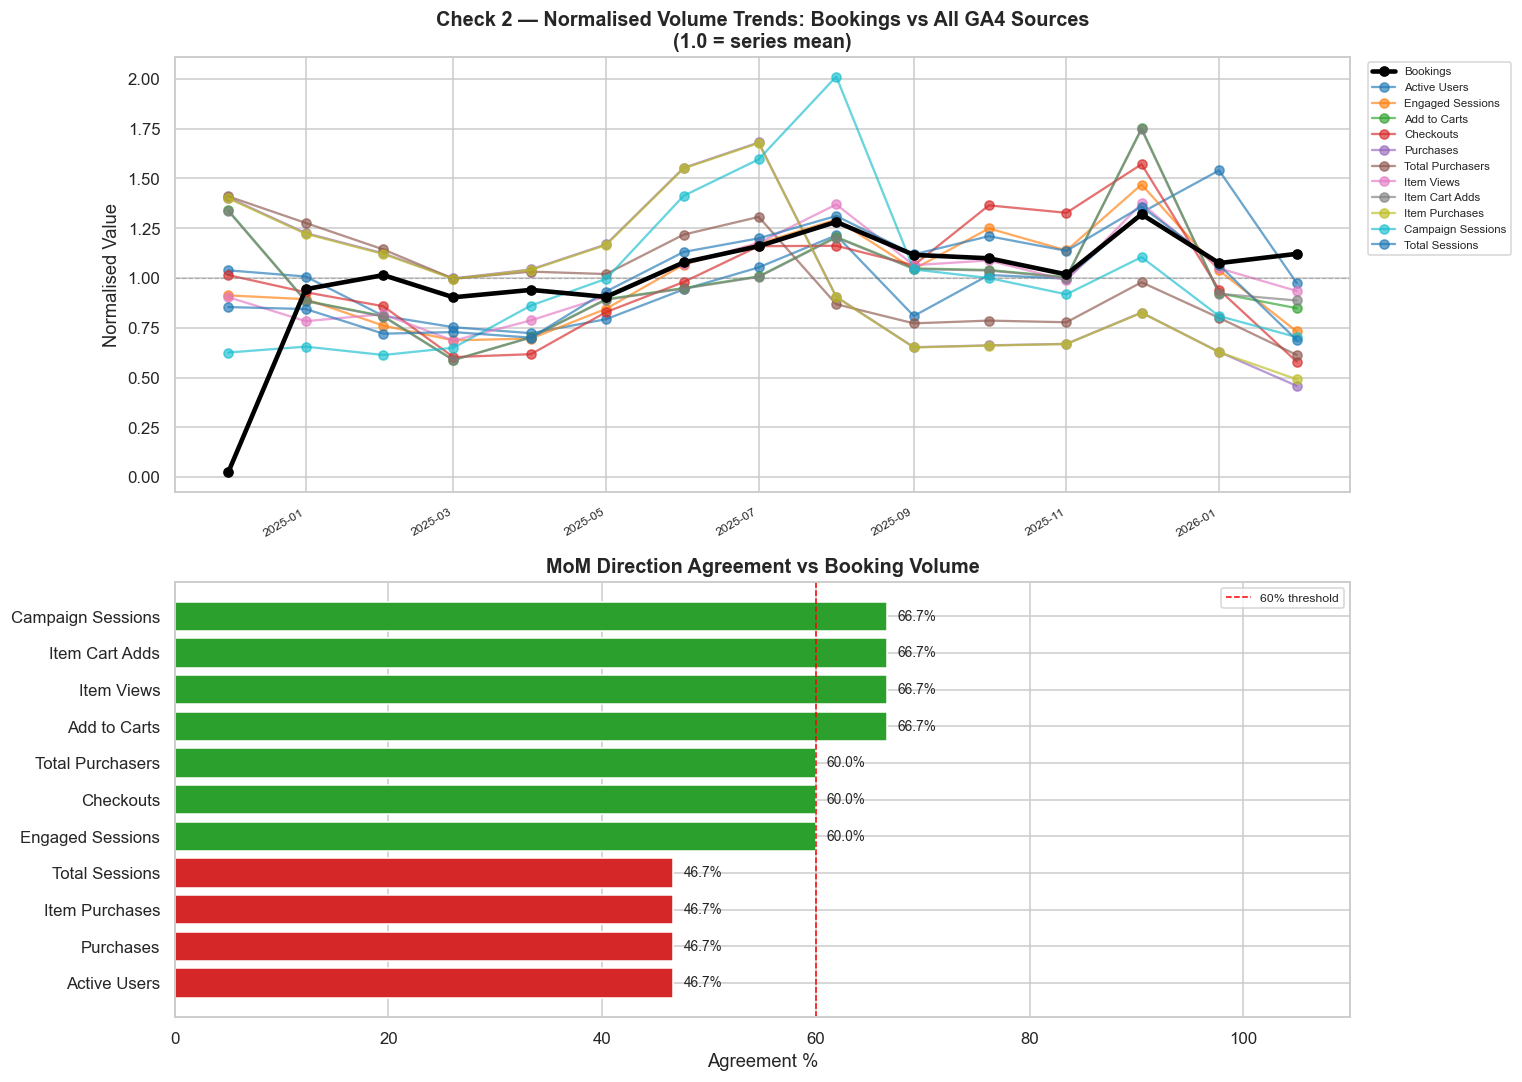

In [100]:
ga4_activity_monthly = ga_activity.rename(columns={'yearMonth': 'year_month'})

ga4_impact_monthly = (
    ga_ci
    .groupby('yearMonth')
    .agg(
        item_views     = ('itemsViewed',      'sum'),
        item_cart      = ('itemsAddedToCart', 'sum'),
        item_purchases = ('itemsPurchased',   'sum'),
    )
    .reset_index()
    .rename(columns={'yearMonth': 'year_month'})
)

ga4_outreach_monthly = (
    ga_co
    .groupby('yearMonth')['sessions']
    .sum()
    .reset_index(name='campaign_sessions')
    .rename(columns={'yearMonth': 'year_month'})
)

ga4_session_monthly = (
    ga_ss
    .groupby('yearMonth')['sessions']
    .sum()
    .reset_index(name='total_sessions')
    .rename(columns={'yearMonth': 'year_month'})
)
bk_monthly = (
    bk_valid
    .groupby('year_month')
    .agg(
        bookings      = ('id',           'count'),
        unique_guests = ('user_id',      'nunique'),
        total_revenue = ('revenue_thb',  'sum'),
        avg_party     = ('party_size',   'mean'),
    )
    .reset_index()
    .sort_values('year_month')
)
#  Merge everything against bookings 
vol_compare = (
    bk_monthly[['year_month', 'bookings']]
    .merge(ga4_activity_monthly, on='year_month', how='inner')
    .merge(ga4_impact_monthly,   on='year_month', how='left')
    .merge(ga4_outreach_monthly, on='year_month', how='left')
    .merge(ga4_session_monthly,  on='year_month', how='left')
    .sort_values('year_month')
)

# All volume columns to compare 
norm_cols = {
    # agg_user_activity
    'activeUsers':          'Active Users',
    'engagedSessions':      'Engaged Sessions',
    'addToCarts':           'Add to Carts',
    'checkouts':            'Checkouts',
    'ecommercePurchases':   'Purchases',
    'totalPurchasers':      'Total Purchasers',
    # campaign_impact (aggregated)
    'item_views':           'Item Views',
    'item_cart':            'Item Cart Adds',
    'item_purchases':       'Item Purchases',
    # campaigns_outreach
    'campaign_sessions':    'Campaign Sessions',
    # session_source
    'total_sessions':       'Total Sessions',
}

# MoM direction agreement per metric 
bk_dir = vol_compare['bookings'].diff().apply(np.sign)
agree_rates = {}
for col in norm_cols:
    if col in vol_compare.columns:
        ga4_dir = vol_compare[col].diff().apply(np.sign)
        agree_rates[col] = (bk_dir == ga4_dir).mean() * 100

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top: normalised trend overlay
ax = axes[0]
bk_norm = vol_compare['bookings'] / vol_compare['bookings'].mean()
ax.plot(vol_compare['year_month'], bk_norm,
        color='black', linewidth=3, marker='o', label='Bookings', zorder=5)

for i, (col, label) in enumerate(norm_cols.items()):
    if col in vol_compare.columns:
        norm = vol_compare[col] / vol_compare[col].mean()
        ax.plot(vol_compare['year_month'], norm,
                color=PALETTE[i % len(PALETTE)], linewidth=1.5,
                marker='o', alpha=0.65, label=label)

ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Check 2 — Normalised Volume Trends: Bookings vs All GA4 Sources\n(1.0 = series mean)')
ax.set_ylabel('Normalised Value')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.2f}'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Bottom: direction agreement bar chart
ax = axes[1]
agree_series = pd.Series(
    {norm_cols[k]: v for k, v in agree_rates.items()}
).sort_values()

bar_colors = [PALETTE[2] if v >= 60 else PALETTE[3] for v in agree_series.values]
bars = ax.barh(agree_series.index, agree_series.values, color=bar_colors)
ax.axvline(60, color='red', linestyle='--', linewidth=1, label='60% threshold')
ax.set_title('MoM Direction Agreement vs Booking Volume')
ax.set_xlabel('Agreement %')
ax.set_xlim(0, 110)
for bar, val in zip(bars, agree_series.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


---
## Check 3 — Monthly revenue comparison 

check if revenue trends by month are in the same direction; by comparing booking reveune VS GA item level + transaction level revenues
- campaign_impact (itemRevenue) 
- agg_user_activity (purchaseRevenue, totalRevenue)


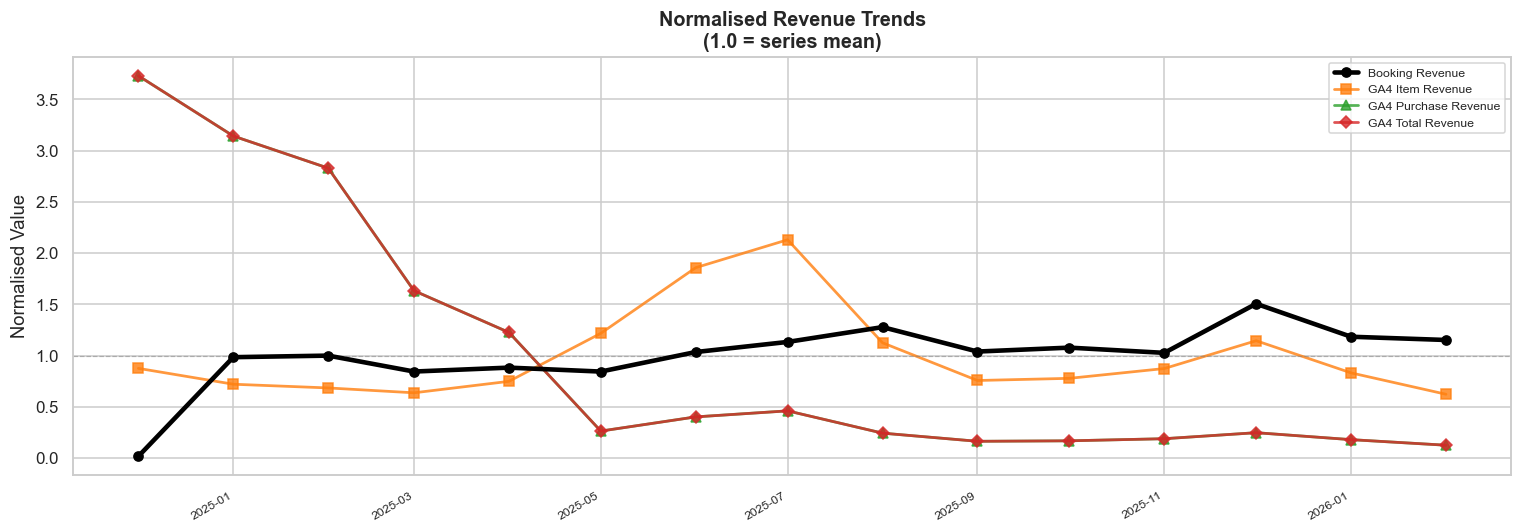

In [97]:
ga4_item_rev = (
    ga_ci
    .groupby('yearMonth')['itemRevenue']
    .sum()
    .reset_index(name='ga4_item_revenue')
    .rename(columns={'yearMonth': 'year_month'})
)

ga4_activity_rev = (
    ga_activity
    .rename(columns={'yearMonth': 'year_month'})
    [['year_month', 'purchaseRevenue', 'totalRevenue']]
)

rev_compare = (
    bk_monthly[['year_month', 'total_revenue']]
    .merge(ga4_item_rev,     on='year_month', how='inner')
    .merge(ga4_activity_rev, on='year_month', how='inner')
    .sort_values('year_month')
)

# Normalise to mean for directional comparison
for col in ['total_revenue', 'ga4_item_revenue', 'purchaseRevenue', 'totalRevenue']:
    rev_compare[f'{col}_norm'] = rev_compare[col] / rev_compare[col].mean()

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(rev_compare['year_month'], rev_compare['total_revenue_norm'],
        color='black', linewidth=3, marker='o', label='Booking Revenue', zorder=5)
ax.plot(rev_compare['year_month'], rev_compare['ga4_item_revenue_norm'],
        color=PALETTE[1], linewidth=1.8, marker='s', alpha=0.8, label='GA4 Item Revenue')
ax.plot(rev_compare['year_month'], rev_compare['purchaseRevenue_norm'],
        color=PALETTE[2], linewidth=1.8, marker='^', alpha=0.8, label='GA4 Purchase Revenue')
ax.plot(rev_compare['year_month'], rev_compare['totalRevenue_norm'],
        color=PALETTE[3], linewidth=1.8, marker='D', alpha=0.8, label='GA4 Total Revenue')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Normalised Revenue Trends\n(1.0 = series mean)')
ax.set_ylabel('Normalised Value')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## Check 5 — Campaign overlap 

check how many campaigns recorded in internal marketing data appears in GA vice versa

**results**
- campaign id and names dont match with each other
- GA data for campaign
    -  GA4 unique campaign names               : 1,182
    - GA4 unique campaign IDs                 : 8,465

In [105]:
# Internal: use campaign name fields available per channel
mkt_crm_names = set(mkt['crm_campaign_name'].dropna().astype(str).str.strip().str.lower())
mkt_fb_names  = set(mkt['fb_campaign'].dropna().astype(str).str.strip().str.lower())
mkt_all_names = mkt_crm_names | mkt_fb_names

# GA4: campaignName (lowercased for matching)
ga4_campaign_names = set(ga_co['campaignName'].dropna().astype(str).str.strip().str.lower())
ga4_campaign_ids   = set(ga_co['campaignId'].dropna().astype(str).str.strip())

name_overlap     = mkt_all_names & ga4_campaign_names
mkt_only_names   = mkt_all_names - ga4_campaign_names
ga4_only_names   = ga4_campaign_names - mkt_all_names

overlap_pct      = len(name_overlap) / len(mkt_all_names) * 100 if mkt_all_names else 0

print('Campaign Overlap Summary:')
print(f'  Internal marketing campaigns (CRM + FB) : {len(mkt_all_names):,}')
print(f'    CRM campaigns                         : {len(mkt_crm_names):,}')
print(f'    FB campaigns                          : {len(mkt_fb_names):,}')
print(f'  GA4 unique campaign names               : {len(ga4_campaign_names):,}')
print(f'  GA4 unique campaign IDs                 : {len(ga4_campaign_ids):,}')
print(f'  Matched (internal ∩ GA4)                : {len(name_overlap):,}  ({overlap_pct:.1f}% of internal)')
print(f'  Internal only (not in GA4)              : {len(mkt_only_names):,}')
print(f'  GA4 only (not in internal)              : {len(ga4_only_names):,}')


Campaign Overlap Summary:
  Internal marketing campaigns (CRM + FB) : 2,371
    CRM campaigns                         : 2,336
    FB campaigns                          : 35
  GA4 unique campaign names               : 1,182
  GA4 unique campaign IDs                 : 8,465
  Matched (internal ∩ GA4)                : 0  (0.0% of internal)
  Internal only (not in GA4)              : 2,371
  GA4 only (not in internal)              : 1,182


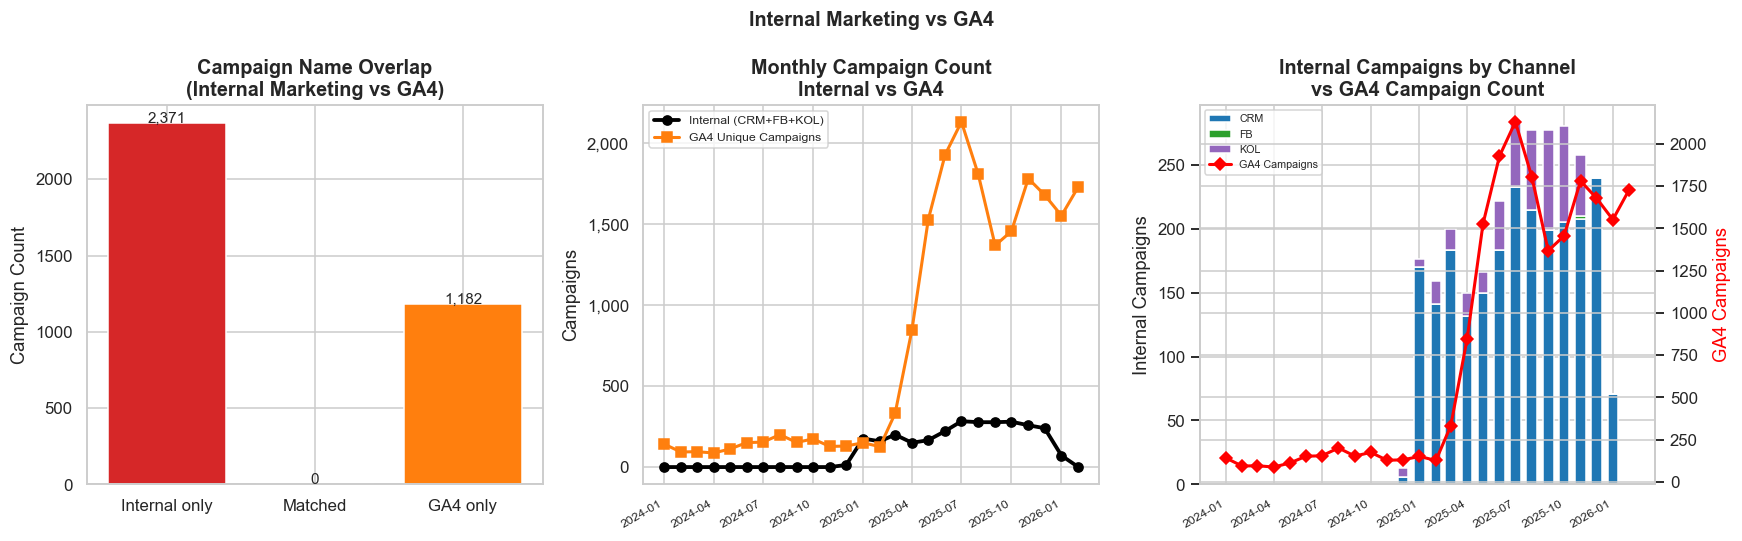

In [109]:
mkt['year_month'] = pd.to_datetime(mkt['activity_start'], errors='coerce').dt.to_period('M').dt.to_timestamp()

ga4_monthly_campaigns = (
    ga_co.groupby('yearMonth')
    .agg(
        ga4_unique_campaigns = ('campaignId',   'nunique'),
        ga4_campaign_sessions= ('sessions',     'sum'),
    )
    .reset_index()
    .rename(columns={'yearMonth': 'year_month'})
)
### comparing only from 2024 data onwards
date_min = max(
    bk_valid['year_month'].min(),
    ga_co['yearMonth'].min(),
)
date_max = min(
    bk_valid['year_month'].max(),
    ga_co['yearMonth'].max(),
)

mkt_filtered = mkt[
    (pd.to_datetime(mkt['activity_start'], errors='coerce') >= date_min) &
    (pd.to_datetime(mkt['activity_start'], errors='coerce') <= date_max)
].copy()

mkt_monthly = (
    mkt_filtered.groupby('year_month')
    .agg(
        crm_campaigns = ('crm_campaign_name', 'nunique'),
        fb_campaigns  = ('fb_campaign',       'nunique'),
        kol_campaigns = ('kol_username',      'nunique'),
    )
    .assign(total_internal=lambda x: x['crm_campaigns'] + x['fb_campaigns'] + x['kol_campaigns'])
    .reset_index()
)
campaign_monthly = (
    mkt_monthly
    .merge(ga4_monthly_campaigns, on='year_month', how='outer')
    .sort_values('year_month')
    .query('year_month >= @date_min and year_month <= @date_max')
)
campaign_monthly = mkt_monthly.merge(ga4_monthly_campaigns, on='year_month', how='outer').sort_values('year_month')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: overlap summary bar
ax = axes[0]
overlap_data = {
    'Internal only': len(mkt_only_names),
    'Matched':        len(name_overlap),
    'GA4 only':       len(ga4_only_names),
}
bar_colors = [PALETTE[3], PALETTE[2], PALETTE[1]]
bars = ax.bar(overlap_data.keys(), overlap_data.values(), color=bar_colors)
ax.set_title('Campaign Name Overlap\n(Internal Marketing vs GA4)')
ax.set_ylabel('Campaign Count')
for bar, val in zip(bars, overlap_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:,}', ha='center', fontsize=10)

# Middle: monthly campaign count comparison
ax = axes[1]
ax.plot(campaign_monthly['year_month'], campaign_monthly['total_internal'].fillna(0),
        marker='o', color='black', linewidth=2.5, label='Internal (CRM+FB+KOL)')
ax.plot(campaign_monthly['year_month'], campaign_monthly['ga4_unique_campaigns'].fillna(0),
        marker='s', color=PALETTE[1], linewidth=2, label='GA4 Unique Campaigns')
ax.set_title('Monthly Campaign Count\nInternal vs GA4')
ax.set_ylabel('Campaigns')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Right: stacked internal breakdown vs GA4
ax = axes[2]
ax.bar(campaign_monthly['year_month'], campaign_monthly['crm_campaigns'].fillna(0),
       label='CRM', color=PALETTE[0], width=20)
ax.bar(campaign_monthly['year_month'], campaign_monthly['fb_campaigns'].fillna(0),
       bottom=campaign_monthly['crm_campaigns'].fillna(0),
       label='FB', color=PALETTE[2], width=20)
ax.bar(campaign_monthly['year_month'], campaign_monthly['kol_campaigns'].fillna(0),
       bottom=campaign_monthly['crm_campaigns'].fillna(0) + campaign_monthly['fb_campaigns'].fillna(0),
       label='KOL', color=PALETTE[4], width=20)
ax2 = ax.twinx()
ax2.plot(campaign_monthly['year_month'], campaign_monthly['ga4_unique_campaigns'].fillna(0),
         marker='D', color='red', linewidth=2, label='GA4 Campaigns')
ax.set_title('Internal Campaigns by Channel\nvs GA4 Campaign Count')
ax.set_ylabel('Internal Campaigns')
ax2.set_ylabel('GA4 Campaigns', color='red')
lines1, l1 = ax.get_legend_handles_labels()
lines2, l2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, l1 + l2, fontsize=7, loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

plt.suptitle('Internal Marketing vs GA4', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Check 6 — Campaign month activity

check if months with more internal campaign activity also show higher GA4 campaign sessions and booking volume; understand rs of internal marketing data, ga campaign data and booking volume


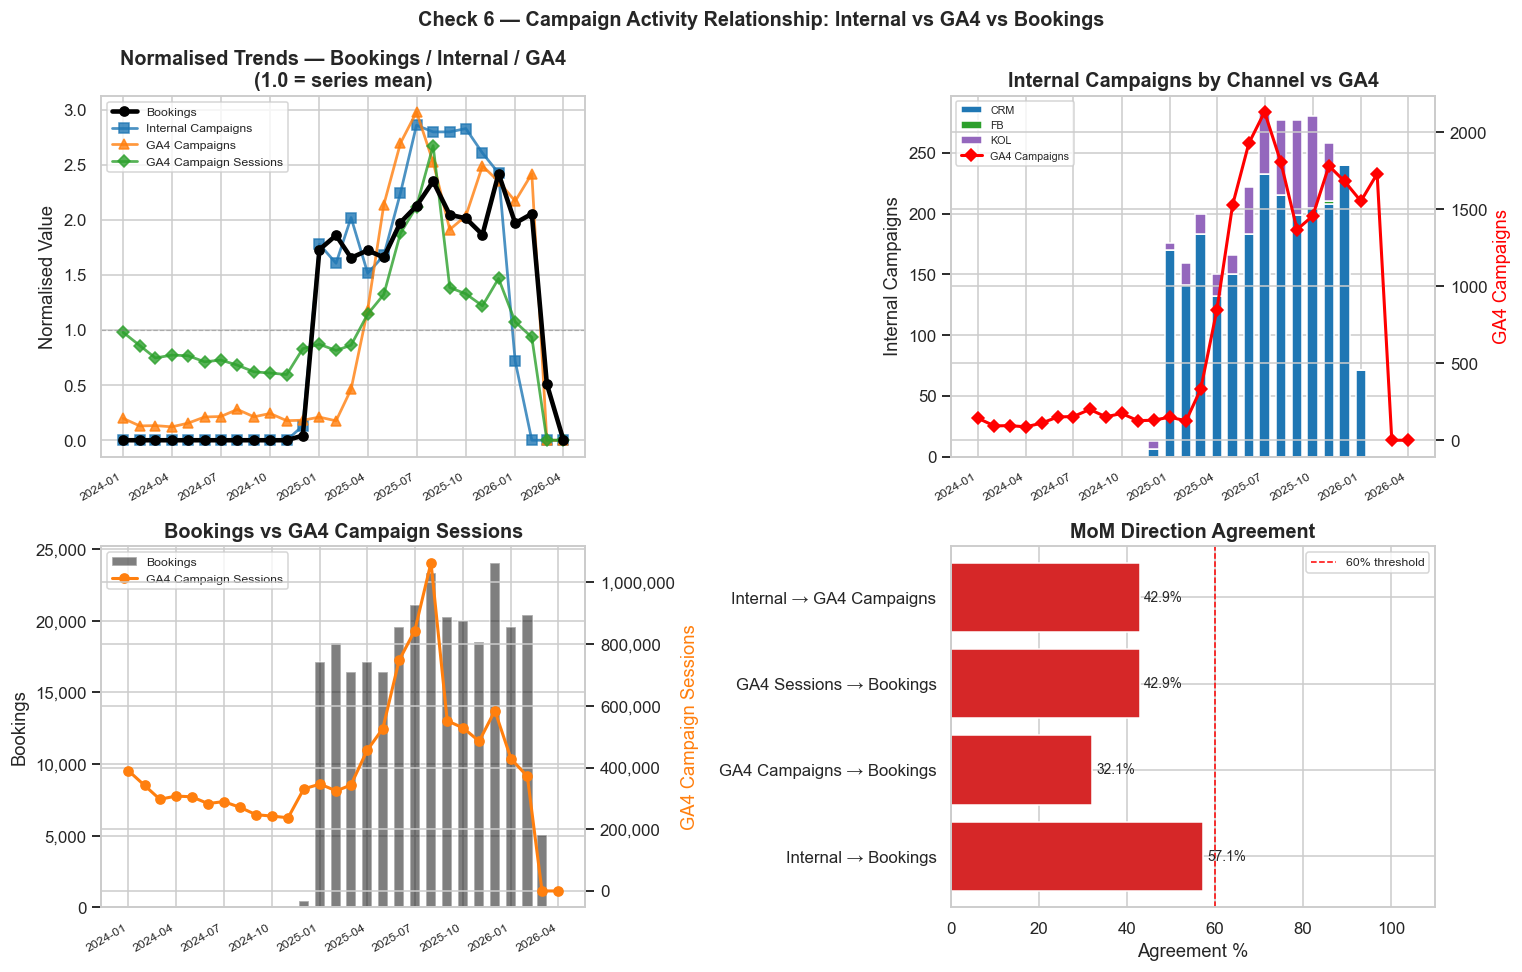

In [111]:
mkt['year_month'] = (
    pd.to_datetime(mkt['activity_start'], errors='coerce')
    .dt.to_period('M').dt.to_timestamp()
)
mkt_filtered = mkt[
    (mkt['year_month'] >= date_min) &
    (mkt['year_month'] <= date_max)
]

mkt_monthly = (
    mkt_filtered
    .groupby('year_month')
    .agg(
        crm_campaigns = ('crm_campaign_name', 'nunique'),
        fb_campaigns  = ('fb_campaign',       'nunique'),
        kol_campaigns = ('kol_username',      'nunique'),
    )
    .assign(total_internal=lambda x: x['crm_campaigns'] + x['fb_campaigns'] + x['kol_campaigns'])
    .reset_index()
)
ga4_monthly_campaigns = (
    ga_co
    .groupby('yearMonth')
    .agg(
        ga4_campaigns = ('campaignId', 'nunique'),
        ga4_sessions  = ('sessions',   'sum'),
    )
    .reset_index()
    .rename(columns={'yearMonth': 'year_month'})
)

camp_compare = (
    bk_monthly[['year_month', 'bookings', 'total_revenue', 'unique_guests']]
    .merge(mkt_monthly,            on='year_month', how='outer')
    .merge(ga4_monthly_campaigns,  on='year_month', how='outer')
    .sort_values('year_month')
    .fillna(0)
)

# Normalise for trend overlay
for col in ['bookings', 'total_internal', 'ga4_campaigns', 'ga4_sessions']:
    mean = camp_compare[col].mean()
    camp_compare[f'{col}_norm'] = camp_compare[col] / mean if mean > 0 else 0

# MoM direction agreement
bk_dir       = camp_compare['bookings'].diff().apply(np.sign)
mkt_dir      = camp_compare['total_internal'].diff().apply(np.sign)
ga4_camp_dir = camp_compare['ga4_campaigns'].diff().apply(np.sign)
ga4_sess_dir = camp_compare['ga4_sessions'].diff().apply(np.sign)

agree_mkt      = (bk_dir == mkt_dir).mean()      * 100
agree_ga4_camp = (bk_dir == ga4_camp_dir).mean() * 100
agree_ga4_sess = (bk_dir == ga4_sess_dir).mean() * 100
agree_mkt_ga4  = (mkt_dir == ga4_camp_dir).mean()* 100

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top left: normalised trend overlay — all three sources
ax = axes[0, 0]
ax.plot(camp_compare['year_month'], camp_compare['bookings_norm'],
        color='black', linewidth=3, marker='o', label='Bookings', zorder=5)
ax.plot(camp_compare['year_month'], camp_compare['total_internal_norm'],
        color=PALETTE[0], linewidth=1.8, marker='s', alpha=0.8, label='Internal Campaigns')
ax.plot(camp_compare['year_month'], camp_compare['ga4_campaigns_norm'],
        color=PALETTE[1], linewidth=1.8, marker='^', alpha=0.8, label='GA4 Campaigns')
ax.plot(camp_compare['year_month'], camp_compare['ga4_sessions_norm'],
        color=PALETTE[2], linewidth=1.8, marker='D', alpha=0.8, label='GA4 Campaign Sessions')
ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
ax.set_title('Normalised Trends — Bookings / Internal / GA4\n(1.0 = series mean)')
ax.set_ylabel('Normalised Value')
ax.legend(fontsize=8)
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Top right: internal campaign channel breakdown stacked
ax = axes[0, 1]
ax.bar(camp_compare['year_month'], camp_compare['crm_campaigns'],
       label='CRM', color=PALETTE[0], width=20)
ax.bar(camp_compare['year_month'], camp_compare['fb_campaigns'],
       bottom=camp_compare['crm_campaigns'],
       label='FB', color=PALETTE[2], width=20)
ax.bar(camp_compare['year_month'], camp_compare['kol_campaigns'],
       bottom=camp_compare['crm_campaigns'] + camp_compare['fb_campaigns'],
       label='KOL', color=PALETTE[4], width=20)
ax2 = ax.twinx()
ax2.plot(camp_compare['year_month'], camp_compare['ga4_campaigns'],
         marker='D', color='red', linewidth=2, label='GA4 Campaigns')
ax.set_title('Internal Campaigns by Channel vs GA4')
ax.set_ylabel('Internal Campaigns')
ax2.set_ylabel('GA4 Campaigns', color='red')
lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, lbls, fontsize=7, loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Bottom left: bookings vs GA4 campaign sessions dual axis
ax = axes[1, 0]
ax2 = ax.twinx()
ax.bar(camp_compare['year_month'], camp_compare['bookings'],
       alpha=0.5, color='black', label='Bookings', width=20)
ax2.plot(camp_compare['year_month'], camp_compare['ga4_sessions'],
         marker='o', color=PALETTE[1], linewidth=2, label='GA4 Campaign Sessions')
ax.set_title('Bookings vs GA4 Campaign Sessions')
ax.set_ylabel('Bookings')
ax2.set_ylabel('GA4 Campaign Sessions', color=PALETTE[1])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
lines = ax.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
lbls  = ax.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax.legend(lines, lbls, fontsize=8, loc='upper left')
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)

# Bottom right: direction agreement summary
ax = axes[1, 1]
agree_labels = [
    'Internal → Bookings',
    'GA4 Campaigns → Bookings',
    'GA4 Sessions → Bookings',
    'Internal → GA4 Campaigns',
]
agree_values = [agree_mkt, agree_ga4_camp, agree_ga4_sess, agree_mkt_ga4]
bar_colors   = [PALETTE[2] if v >= 60 else PALETTE[3] for v in agree_values]
bars = ax.barh(agree_labels, agree_values, color=bar_colors)
ax.axvline(60, color='red', linestyle='--', linewidth=1, label='60% threshold')
ax.set_title('MoM Direction Agreement')
ax.set_xlabel('Agreement %')
ax.set_xlim(0, 110)
for bar, val in zip(bars, agree_values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend(fontsize=8)

plt.suptitle('Check 6 — Campaign Activity Relationship: Internal vs GA4 vs Bookings',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
